# Modelo Preditivo Bill Hunters

Este notebook tem como objetivo realizar o carregamento, padronização, limpeza e análise de dados dos boletos, preparando-os para a aplicação do modelos de Machine Learning proposto no módulo. O fluxo do notebook segue as etapas:

### **Sumário**

0. **Como executar o código?**: Trata do básico de como executar os algoritimos.
1. **Instalação de dependências**: Garante que as bibliotecas necessárias estejam disponíveis.
2. **Carregamento dos dados**: Lê os arquivos Excel contendo os dados de cobranças.
3. **Padronização e unificação**: Renomeia colunas e unifica os dados em um único DataFrame.
4. **Limpeza e pré-processamento**: Trata valores ausentes, converte tipos de dados e remove registros inválidos.
5. **Engenharia de atributos**: Cria novas colunas relevantes para análise, como dias de atraso e status do pagamento.
6. **Análise de outliers**: Identifica e trata valores extremos nos dados.
7. **Modelagem do problema e engenharia de features**: Define o problema de negócio e seleciona features relevantes.
8. **Treinamento do modelo**: Implementa e treina o RandomForestClassifier.
9. **Discussão dos resultados do modelo candidato**: Interpreta os resultados e discute limitações.
10. **Aplicação prática do modelo**: Demonstra o uso do modelo com exemplos reais.
    - 10.1. Exemplo de uso com dados fictícios
    - 10.2. Exemplo com dados reais do dataset
    - 10.3. Discussão crítica dos resultados
    - 10.4. Metodologia utilizada


### **0. Como executar o código?**


Tecnologias obrigatorias:

**Utilizar pip3 ou pip e em seguida escrever a tecnologia a ser baixada:**

* **`Python3`**: Versão do python utilizado;

* **`pandas`**: Para manipulação e análise de dados, sendo a principal ferramenta para carregar e transformar as tabelas.

* **`numpy`**: Para operações numéricas eficientes, usada em conjunto com o pandas.

* **`scikit-learn`**: A biblioteca central de Machine Learning, de onde utilizamos o modelo `RandomForestClassifier`, as métricas de avaliação e as funções de pré-processamento.

* **`openpyxl`**: Uma dependência do pandas necessária para ler e manipular arquivos no formato `.xlsx`.

* **`jupyterlab` ou `jupyter-notebook`**: Para a criação do ambiente de desenvolvimento interativo onde o código foi escrito e executado.

**Configuração do Ambiente de Execução**

Para garantir que o projeto funcione em qualquer máquina sem conflitos de versão, é fundamental utilizar um **ambiente virtual (`venv`)**.

Criar o Ambiente Virtual:

Abra o Terminal, navegue até a pasta onde o projeto está localizado e execute o seguinte comando para criar uma pasta `venv` que conterá o ambiente:

```bash
python3 -m venv venv

### **1. Instalando Dependências**

##### Importando módulos básicos e essenciais para atender as necessidades do projeto.

Primeiro são instaladas as bibliotecas necessárias para leitura e análise dos dados, garantindo o ambiente correto; em seguida, os arquivos Excel são carregados e unificados em um único DataFrame, criando a base consolidada para as próximas etapas do projeto.



- `import sys` importa o módulo **`sys`**, que contém informações sobre o próprio interpretador Python.  

- `!{sys.executable} -m pip install openpyxl`  esse comando pede para o **mesmo Python que você está usando** instalar a biblioteca **`openpyxl`**.  

- O **`{sys.executable}`** garante que a instalação vai acontecer no ambiente correto (e não em outro Python do sistema).  

- **`pip install openpyxl`** faz a instalação em si.  



In [ ]:
import sys
!{sys.executable} -m pip install openpyxl

In [9]:
import pandas as pd
import numpy as np
import sklearn

Cada módulo é associado a uma nome curto (como `pd` e `np` ) para facilitar seu uso no código.


### **2. Carregamento dos dados**

Antes de realizar qualquer análise ou construção de modelos, é fundamental garantir que os dados estejam devidamente carregados em uma estrutura que permita manipulação e exploração eficiente. Nesta etapa, utilizamos o pandas, uma das bibliotecas mais poderosas em Python para análise de dados, com o intuito de ler arquivos Excel e transformá-los em DataFrames.

#### 1. Seleção dos datasets:

- Foram selecionados quatro arquivos de planilhas, cada um representando um grupo distinto de dados de cobrança, para garantir uma análise abrangente e diversificada.


`df1= pd.read_excel("../dados/Grupo1-GL.xlsx")`
- Cada arquivo é carregado em um DataFrame separado usando a função `pd.read_excel()`, que lê os dados do Excel e os armazena em uma estrutura tabular do pandas para fácil manipulação e análise.

`df = pd.concat([df1,df2,df3, df4] ,ignore_index = True)` 
- Para que os dados possam ser analisados de forma conjunta, os quatro DataFrames são concatenados em um único DataFrame `df` usando `pd.concat()`. O parâmetro `ignore_index=True` é utilizado para resetar os índices do novo DataFrame, garantindo uma sequência contínua.

In [ ]:
#Carrega o arquivo Excel
df1= pd.read_excel("../dados/Grupo1-GL.xlsx")
df2= pd.read_excel("../dados/Grupo3-GP.xlsx")
df3= pd.read_excel("../dados/Grupo4-GT.xlsx")
df4= pd.read_excel("../dados/Grupo2-GM.xlsx")
#Une os todos os arquivos 
df = pd.concat([df1,df2,df3, df4] ,ignore_index = True)
df.head()

,id_grupo,id_beneficiario,Numero_do_boleto,data_inclusao,status_boleto,data_vencto,vl_boleto,dt_pagto,vl_pagto,banco,...,pagador_cidade,qtd_acessos_pagador,pagador_dt_ultimo_acesso,pagador_cnpjcpf,pagador_inscricao_hash,valor_abatimento,tipo_juros,juros,tipo_multa,multa
0,173,554,426309011,2024-11-25,REGISTRADO,2025-12-03 00:00:00,188645.00,\N,\N,ITAU UNIBANCO S.A.,...,CAMPO GRANDE,\N,\N,CNPJ,dc1e3c141c9c7d7408b783c9d4f48bc3721dd9621e4fd4...,0.0,M,62.88,P,2.0
1,173,554,426702880,2024-11-26,REGISTRADO,2025-12-03 00:00:00,69386.15,\N,\N,ITAU UNIBANCO S.A.,...,CAMPO GRANDE,\N,\N,CNPJ,dc1e3c141c9c7d7408b783c9d4f48bc3721dd9621e4fd4...,0.0,M,23.13,P,2.0
2,173,554,427422093,2024-11-28,REGISTRADO,2025-12-03 00:00:00,21717.33,\N,\N,ITAU UNIBANCO S.A.,...,CAMPO GRANDE,\N,\N,CNPJ,dc1e3c141c9c7d7408b783c9d4f48bc3721dd9621e4fd4...,0.0,M,7.24,P,2.0
3,173,554,439264582,2025-01-21,REGISTRADO,2025-05-12 00:00:00,221338.95,\N,\N,ITAU UNIBANCO S.A.,...,BRASILIA,\N,\N,CNPJ,04ffcdcdbb6d616c87ab1c9a5e59586dbc46f95c0e4e98...,0.0,M,73.78,P,2.0
4,173,554,439264583,2025-01-21,REGISTRADO,2025-05-12 00:00:00,110669.49,\N,\N,ITAU UNIBANCO S.A.,...,BRASILIA,\N,\N,CNPJ,04ffcdcdbb6d616c87ab1c9a5e59586dbc46f95c0e4e98...,0.0,M,36.89,P,2.0


#### 2. Verificação dos tipos de dados:
Verificar os tipos das variáveis em uma tabela é essencial para garantir que os dados sejam interpretados corretamente, evitando erros de análise e assegurando resultados confiáveis.  

`df.dtypes` 
- Função que exibe os tipos de dados de cada coluna no DataFrame, permitindo identificar se estão adequados para as operações que serão realizadas posteriormente.

In [ ]:
df.dtypes

id_grupo\tid_beneficiario\tNumero_do_boleto\tdata_inclusao\tstatus_boleto\tdata_vencto\tvl_boleto\tdt_pagto\tvl_pagto\tbanco\tid_pagador\tpagador_cep\tpagador_cidade\tqtd_acessos_pagador\tpagador_dt_ultimo_acesso\tpagador_cnpjcpf\tpagador_inscricao_hash\tvalor_abatimento\ttipo_juros\tjuros\ttipo_multa\tmulta    object
dtype: object

#### 3. Separação das colunas numéricas e categóricas

- Separar as colunas em numéricas e categóricas é importante porque cada tipo de dado exige técnicas de análise e tratamento diferentes, permitindo aplicar cálculos estatísticos às variáveis numéricas e métodos de agrupamento ou codificação às variáveis categóricas.  



In [ ]:
colunas_numericas = df.select_dtypes(include = ['int64', 'float64']).columns
colunas_categoricas = df.select_dtypes(include = ['object']).columns

print("Colunas Numericas:", colunas_numericas)
print("Colunas Categoricas:", colunas_categoricas)

Colunas Numericas: Index(['id_grupo', 'id_beneficiario', 'Numero_do_boleto', 'id_pagador'], dtype='object')
Colunas Categoricas: Index(['status_boleto', 'data_vencto', 'vl_boleto', 'dt_pagto', 'vl_pagto',
       'banco', 'pagador_cep', 'pagador_cidade', 'qtd_acessos_pagador',
       'pagador_dt_ultimo_acesso', 'pagador_cnpjcpf', 'pagador_inscricao_hash',
       'valor_abatimento', 'tipo_juros', 'juros', 'tipo_multa', 'multa'],
      dtype='object')


`df.describe()`
- Comando gera um resumo estatístico das colunas numéricas do DataFrame, mostrando informações como contagem de valores (`count`), média (`mean`), desvio padrão (`std`), valores mínimo e máximo (`min` e `max`), além dos quartis (25%, 50% e 75%), ajudando a entender rapidamente a distribuição dos dados. Tudo isso permite identificar a distribuição das variáveis, detectar valores ausentes ou extremos (outliers), verificar escalas diferentes entre colunas e garantir que os dados estejam consistentes antes de aplicar técnicas de normalização ou padronização, que são essenciais para muitos algoritmos de Machine Learning.


In [ ]:
df.describe()

,id_grupo,id_beneficiario,Numero_do_boleto,data_inclusao,id_pagador
count,1.202864e+06,1.202864e+06,1.202864e+06,1202864,1.202864e+06
mean,1.495497e+02,4.875801e+02,4.309226e+08,2024-12-23 07:35:52.534616832,1.300437e+07
min,1.120000e+02,3.660000e+02,3.790359e+08,2024-07-01 00:00:00,1.066354e+06
25%,1.120000e+02,3.660000e+02,4.099548e+08,2024-09-18 00:00:00,3.250834e+06
50%,1.620000e+02,5.340000e+02,4.307782e+08,2024-12-12 00:00:00,1.912229e+07
75%,1.790000e+02,5.620000e+02,4.552684e+08,2025-03-31 00:00:00,2.015086e+07
max,1.790000e+02,1.497000e+03,4.765224e+08,2025-06-30 00:00:00,2.113715e+07
std,2.924961e+01,1.152362e+02,2.812272e+07,NaN,8.129189e+06


### **3. Padronização e Unificação**

#### 1. Unificação dos dados:

Nesta etapa, o foco é organizar e unificar os diferentes arquivos de dados em uma estrutura única e padronizada. Ao reunir todas as planilhas em uma lista, é possível automatizar a leitura e consolidação das informações em um só DataFrame, o que facilita a manipulação, reduz inconsistências e garante que a análise seja feita de forma conjunta.

`arquivos_excel`
- Variável que armazena a lista dos caminhos dos quatro arquivos Excel que contêm os dados de cobrança a serem carregados e unificados em um único DataFrame para análise conjunta.

In [15]:
print("Passo 1: Carregando e Estuturando os dados, importando as bibliotecas necessárias")

arquivos_excel = [
    "../dados/Grupo1-GL.xlsx",
    "../dados/Grupo3-GP.xlsx",
    "../dados/Grupo4-GT.xlsx",
    "../dados/Grupo2-GM.xlsx"
]

#### 2. Padronização dos nomes das colunas:

Aqui é feita a padronização dos nomes das colunas, etapa fundamental para unificar os diferentes formatos vindos das planilhas originais. Por meio de um dicionário de mapeamento, os nomes variados são convertidos em rótulos consistentes, o que simplifica a manipulação, evita erros em etapas posteriores e garante que todas as análises usem uma nomenclatura uniforme.

`mapa_de_colunas`
- Dicionário que mapeia os nomes originais das colunas dos arquivos Excel para nomes padronizados, facilitando a unificação e manipulação dos dados posteriormente.

In [ ]:
mapa_de_colunas = {
    'data_vencto': 'data_vencimento',
    'vl_boleto': 'valor_original',
    'dt_pagto': 'data_pagamento',
    'vl_pagto': 'valor_pago',
    'id_pagador': 'pagador',
    'banco_emissor': 'banco',
    'qtd_acessos_pagador': 'qtde_acessado_pagador',
    'teve_acesso_pagador': 'teve_acesso_pagador',
    'pagador_cep': 'pagador_cep',
    'pagador_cidade': 'pagador_cidade',
    'status_boleto': 'status_boleto',
    'data_inclusao': 'data_inclusao',
    'grupo': 'grupo',
    'empresa': 'empresa'
}

#### 3. Transformação do banco de dados em DataFrame unificado e organizado
- o código percorre uma lista de arquivos Excel, lê cada um, padroniza os nomes das colunas, junta todos em um único DataFrame e mostra o total de linhas carregadas.


`lista_de_dfs = []` 
- cria uma lista vazia para armazenar os DataFrames carregados. 

`for arquivo in arquivos_excel:` 
- percorre cada arquivo Excel da lista de caminhos.  

`df_temp.columns = df_temp.columns.str.lower()` 
-  converte todos os nomes de colunas para letras minúsculas.  

`df_temp.rename(columns=mapa_de_colunas, inplace=True)` 
- renomeia as colunas de acordo com o dicionário `mapa_de_colunas`.    


In [18]:
lista_de_dfs = []

print("\nLendo e padronizando os arquivos...")
for arquivo in arquivos_excel:
    try:
        df_temp = pd.read_excel(arquivo)
        
        
        df_temp.columns = df_temp.columns.str.lower()
        
        df_temp.rename(columns=mapa_de_colunas, inplace=True)
        
        lista_de_dfs.append(df_temp)
        print(f"  - Arquivo '{arquivo}' carregado e padronizado com sucesso.")
    except FileNotFoundError:
        print(f"  - ATENÇÃO: Arquivo '{arquivo}' não encontrado. Verifique se o nome está correto.")
    except Exception as e:
        print(f"  - ERRO ao processar o arquivo '{arquivo}': {e}")

df = pd.concat(lista_de_dfs, ignore_index=True)

print("\nArquivos unificados com sucesso!")
print(f"Total de linhas carregadas de todos os arquivos: {len(df)}")


Lendo e padronizando os arquivos...
  - Arquivo '../dados/Grupo1-GL.xlsx' carregado e padronizado com sucesso.
  - Arquivo '../dados/Grupo3-GP.xlsx' carregado e padronizado com sucesso.
  - Arquivo '../dados/Grupo4-GT.xlsx' carregado e padronizado com sucesso.
  - Arquivo '../dados/Grupo2-GM.xlsx' carregado e padronizado com sucesso.

Arquivos unificados com sucesso!
Total de linhas carregadas de todos os arquivos: 1202864


#### 3. Substituição e Remoção:

`df.replace('\\N', np.nan, inplace=True)`
 - Nesta etapa, realizamos a substituição de valores nulos e a remoção de inconsistências para garantir a qualidade dos dados. Marcadores de texto inválidos são transformados em NaN, permitindo que as informações ausentes sejam tratadas de forma adequada. Esse processo é fundamental para evitar erros em análises posteriores e garantir que apenas registros válidos e completos sejam utilizados no modelo.

In [24]:
if lista_de_dfs:
    df.replace('\\N', np.nan, inplace=True)
    print("\nDados carregados e colunas padronizadas!")
    print("\nPrimeiras 5 linhas do DataFrame UNIFICADO:")
    print(df.head())
else:
    print("\nERRO CRÍTICO: Nenhum arquivo foi carregado. Verifique os nomes e caminhos dos arquivos.")

/var/folders/f4/9yt_2mc11_j28v6p0byhbk580000gn/T/ipykernel_20773/3613959166.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('\\N', np.nan, inplace=True)



Dados carregados e colunas padronizadas!

Primeiras 5 linhas do DataFrame UNIFICADO:
   id_grupo  id_beneficiario  numero_do_boleto data_inclusao status_boleto  \
0       173              554         426309011    2024-11-25    REGISTRADO   
1       173              554         426702880    2024-11-26    REGISTRADO   
2       173              554         427422093    2024-11-28    REGISTRADO   
3       173              554         439264582    2025-01-21    REGISTRADO   
4       173              554         439264583    2025-01-21    REGISTRADO   

       data_vencimento valor_original data_pagamento valor_pago  \
0  2025-12-03 00:00:00      188645.00            NaT        NaN   
1  2025-12-03 00:00:00       69386.15            NaT        NaN   
2  2025-12-03 00:00:00       21717.33            NaT        NaN   
3  2025-05-12 00:00:00      221338.95            NaT        NaN   
4  2025-05-12 00:00:00      110669.49            NaT        NaN   

                banco  ...  pagador_cidade

### **4. Limpeza e Pré Processamento**

Aqui ocorre a limpeza e preparação inicial dos dados, tratando valores ausentes e ajustando tipos de variáveis para formatos adequados. Esse processo é essencial para evitar vieses e inconsistências, além de garantir que cálculos, comparações e análises estatísticas sejam executados corretamente. Assim, datas são convertidas para o formato datetime, valores monetários para numérico, e registros inválidos são padronizados como nulos, preparando uma base confiável para a modelagem.

### 1. Tratamento de Missing Values:

- tratamento de missing values é crucial para evitar vieses na análise e melhorar a precisão dos modelos preditivos, assegurando que as conclusões tiradas sejam confiáveis e representativas do fenômeno estudado.

- Anets de remover os valores nulos, foi preciso transformar os dados para o formato correto:


`pd.to_datetime`
- Transforma as datas que estão em formato de texto para o formato datetime do pandas, facilitando operações como cálculos de diferença entre datas e filtragem por períodos.



`pd.to_numeric`
- Transforma os valores dos boletos que estavam em formato de texto em valor numérico, permitindo cálculos matemáticos e análises estatísticas.


 `*errors='coerce'*`
  - Transforma um dado que não seja data ou numérico para um valor nulo para evitar erros na análise.


*OBS:* Um valor nulo na coluna `qtde_acessado_pagador` vira 0, ou seja, significa que o cliente nunca acessou o boleto, um valor útil para o modelo.



In [25]:
print("Passo 2: Pré Processamento dos dados")

linhas_iniciais = len(df)
print(f"Número de linhas antes da limpeza: {linhas_iniciais}")

print("\nIniciando conversão de tipos e limpeza...")

df['data_vencimento'] = pd.to_datetime(df['data_vencimento'], format='%Y-%m-%d', errors='coerce')
df['data_pagamento'] = pd.to_datetime(df['data_pagamento'], format='%Y-%m-%d', errors='coerce')
df['valor_original'] = pd.to_numeric(df['valor_original'], errors='coerce')
df['qtde_acessado_pagador'] = pd.to_numeric(df['qtde_acessado_pagador'], errors='coerce').fillna(0)


Passo 2: Pré Processamento dos dados
Número de linhas antes da limpeza: 1202864

Iniciando conversão de tipos e limpeza...




`df.dropna(subset=['data_vencimento', 'valor_original', 'pagador'], inplace=True)`
- Remove todas as linhas que possuem valores nulos nas colunas `'data_vencimento'`, `'valor_original'` e `'pagador'`. Isso garante que apenas cobranças com informações completas e relevantes sejam mantidas para o treinamento do modelo. Ao eliminar registros incompletos, evitamos que dados inconsistentes prejudiquem a qualidade do aprendizado, resultando em previsões mais confiáveis e precisas.

In [26]:
df.dropna(subset=['data_vencimento', 'valor_original', 'pagador'], inplace=True)

linhas_finais = len(df)
linhas_removidas = linhas_iniciais - linhas_finais
print(f"Limpeza concluída. Foram removidas {linhas_removidas} linhas com dados essenciais ausentes.")
print(f"Número de linhas após a limpeza: {linhas_finais}")
print(f"Percentual de dados válidos retidos: {((linhas_finais / linhas_iniciais) * 100):.2f}%")

Limpeza concluída. Foram removidas 30202 linhas com dados essenciais ausentes.
Número de linhas após a limpeza: 1172662
Percentual de dados válidos retidos: 97.49%


- Criando uma única coluna numérica a partir de duas colunas

Essa Coluna numérica é responsável por definir os dias de atraso do pagamento (diferença entre data de pagamento e vencimento), servindo como base para a função *definir_status*. 

In [27]:
df['dias_de_atraso'] = (df['data_pagamento'] - df['data_vencimento']).dt.days

### **5. Engenharia de Atributos**

Para melhorar a performance do modelo preditivo, foram criadas novas colunas que agregam valor aos dados originais, facilitando a identificação de padrões relevantes para a classificação das cobranças.

`definir_status`
- **Definição:** Função que classifica o status de pagamento de uma cobrança com base na data de vencimento e na data de pagamento, retornando 'Inadimplente', 'Em Dia' ou 'Atraso' conforme as condições definidas.

- **Aplicação:** Essa classificação é fundamental, pois define a variável-alvo que será prevista pelo modelo de Machine Learning. O que significa que o modelo aprenderá a identificar padrões nos dados que levam a cada um desses status, permitindo prever o comportamento futuro das cobranças com base em suas características históricas.

In [28]:
def definir_status(dias):
    if pd.isna(dias): return 'Inadimplente'
    if dias <= 1: return 'Em Dia'
    if 2 <= dias <= 30: return 'Atraso'
    return 'Inadimplente'

df['status_pagamento'] = df['dias_de_atraso'].apply(definir_status)

print("\nRelatório Final do Pré-processamento")
print("Distribuição do Status de Pagamento (dados unificados e limpos):")
print(df['status_pagamento'].value_counts())
print("\nPré-processamento finalizado. Os dados estão prontos para o treinamento do modelo.")


Relatório Final do Pré-processamento
Distribuição do Status de Pagamento (dados unificados e limpos):
status_pagamento
Inadimplente    521308
Em Dia          458497
Atraso          192857
Name: count, dtype: int64

Pré-processamento finalizado. Os dados estão prontos para o treinamento do modelo.



**Funcionamento da função:**

- Se o valor de `dias` for nulo, significa que não houve pagamento registrado para aquela cobrança, então ela é considerada `Inadimplente`.
- Se o pagamento foi feito com até 1 dia de atraso, o status é `Em Dia`.
- Se o pagamento ocorreu entre 2 e 30 dias após o vencimento, o status é `Atraso`.
- Para atrasos superiores a 30 dias, a cobrança também é classificada como `Inadimplente`.

Após definir essas regras, aplicamos a função a cada linha do DataFrame usando o método `.apply(definir_status)`, preenchendo a coluna `status_pagamento` com a classificação correspondente para cada registro.



---

### OBS.: Feito na sprint 3:

---

### **6. Análise de Outliers**

A dectecção e tratamento de outliers é uma etapa crucial na preparação dos dados para modelos de Machine Learning, pois esses valores extremos podem distorcer análises estatísticas e prejudicar a acurácia do modelo. 


-  Veremos abaixo como tratar outliers utilizando quartils e o método IQR (Interquartile Range). 

- Importando funções e métodos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

- Visualização inicial do df recebido

In [145]:
df.head()

,id_grupo,id_beneficiario,numero_do_boleto,data_inclusao,status_boleto,data_vencimento,valor_original,data_pagamento,valor_pago,banco,...,pagador_dt_ultimo_acesso,pagador_cnpjcpf,pagador_inscricao_hash,valor_abatimento,tipo_juros,juros,tipo_multa,multa,dias_de_atraso,status_pagamento
0,173,554,426309011,2024-11-25,REGISTRADO,2025-12-03,188645.00,NaT,NaN,ITAU UNIBANCO S.A.,...,NaT,CNPJ,dc1e3c141c9c7d7408b783c9d4f48bc3721dd9621e4fd4...,0.0,M,62.88,P,2.0,NaN,Inadimplente
1,173,554,426702880,2024-11-26,REGISTRADO,2025-12-03,69386.15,NaT,NaN,ITAU UNIBANCO S.A.,...,NaT,CNPJ,dc1e3c141c9c7d7408b783c9d4f48bc3721dd9621e4fd4...,0.0,M,23.13,P,2.0,NaN,Inadimplente
2,173,554,427422093,2024-11-28,REGISTRADO,2025-12-03,21717.33,NaT,NaN,ITAU UNIBANCO S.A.,...,NaT,CNPJ,dc1e3c141c9c7d7408b783c9d4f48bc3721dd9621e4fd4...,0.0,M,7.24,P,2.0,NaN,Inadimplente
3,173,554,439264582,2025-01-21,REGISTRADO,2025-05-12,221338.95,NaT,NaN,ITAU UNIBANCO S.A.,...,NaT,CNPJ,04ffcdcdbb6d616c87ab1c9a5e59586dbc46f95c0e4e98...,0.0,M,73.78,P,2.0,NaN,Inadimplente
4,173,554,439264583,2025-01-21,REGISTRADO,2025-05-12,110669.49,NaT,NaN,ITAU UNIBANCO S.A.,...,NaT,CNPJ,04ffcdcdbb6d616c87ab1c9a5e59586dbc46f95c0e4e98...,0.0,M,36.89,P,2.0,NaN,Inadimplente


- Visualização dos tipos das variáveis do df recebido

In [146]:
df.dtypes

id_grupo                             int64
id_beneficiario                      int64
numero_do_boleto                     int64
data_inclusao               datetime64[ns]
status_boleto                       object
data_vencimento             datetime64[ns]
valor_original                     float64
data_pagamento              datetime64[ns]
valor_pago                          object
banco                               object
pagador                              int64
pagador_cep                         object
pagador_cidade                      object
qtde_acessado_pagador              float64
pagador_dt_ultimo_acesso    datetime64[ns]
pagador_cnpjcpf                     object
pagador_inscricao_hash              object
valor_abatimento                    object
tipo_juros                          object
juros                               object
tipo_multa                          object
multa                               object
dias_de_atraso                     float64
status_paga

- Gerando df com somente as features úteis para o modelo e verificando seus tipos

In [147]:
df_rdForest = df[['data_inclusao', 'data_vencimento', 'valor_original', 'banco', 'status_pagamento']]
df_rdForest.dtypes

data_inclusao       datetime64[ns]
data_vencimento     datetime64[ns]
valor_original             float64
banco                       object
status_pagamento            object
dtype: object

- Transformando colunas datetime64 para colunas numéricas

>Precisamos transformar, pois, o método RandomForest aceita somente valores numéricos.

In [148]:
df_rdForest["ano_inclusao"] = df_rdForest["data_inclusao"].dt.year
df_rdForest["mes_inclusao"] = df_rdForest["data_inclusao"].dt.month
df_rdForest["dia_inclusao"] = df_rdForest["data_inclusao"].dt.day
df_rdForest["dias_para_vencimento"] = (df_rdForest["data_vencimento"] - df_rdForest["data_inclusao"]).dt.days

df_rdForest.dtypes


C:\Users\Inteli\AppData\Local\Temp\ipykernel_35948\3011583627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rdForest["ano_inclusao"] = df_rdForest["data_inclusao"].dt.year
C:\Users\Inteli\AppData\Local\Temp\ipykernel_35948\3011583627.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rdForest["mes_inclusao"] = df_rdForest["data_inclusao"].dt.month
C:\Users\Inteli\AppData\Local\Temp\ipykernel_35948\3011583627.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

data_inclusao           datetime64[ns]
data_vencimento         datetime64[ns]
valor_original                 float64
banco                           object
status_pagamento                object
ano_inclusao                     int32
mes_inclusao                     int32
dia_inclusao                     int32
dias_para_vencimento             int64
dtype: object

- Retirando colunas datetime, visto que não serão utilizadas

In [149]:
df_rdForest = df_rdForest.drop(columns=['data_inclusao', 'data_vencimento'])

- Transformando a coluna "banco" tipo objetc em coluna numérica

>Precisamos transformar, pois, o método RandomForest aceita somente valores numéricos.

In [150]:
df_rdForest = pd.get_dummies(df_rdForest, columns=["banco"])

df_rdForest.dtypes


valor_original                         float64
status_pagamento                        object
ano_inclusao                             int32
mes_inclusao                             int32
dia_inclusao                             int32
dias_para_vencimento                     int64
banco_BANCO ABC BRASIL S.A.               bool
banco_BANCO BBM BOCOM                     bool
banco_BANCO BRADESCO SA                   bool
banco_BANCO CITIBANK S.A.                 bool
banco_BANCO DAYCOVAL                      bool
banco_BANCO DO BRASIL                     bool
banco_BANCO SAFRA                         bool
banco_BANCO SANTANDER (BRASIL) S.A.       bool
banco_ITAU UNIBANCO S.A.                  bool
dtype: object

- Transformando todos os valores menos status_pagamento para Int

>Dessa forma garantimos que não haverá interpretação incorreta pelo método RandomForest

In [151]:
cols = df_rdForest.columns.difference(["status_pagamento"])
df_rdForest[cols] = df_rdForest[cols].astype(int)


- Visualização do df pós processamento
    - Head;
    - Tipos.

In [164]:
df_rdForest.head()

,valor_original,status_pagamento,ano_inclusao,mes_inclusao,dia_inclusao,dias_para_vencimento,banco_BANCO ABC BRASIL S.A.,banco_BANCO BBM BOCOM,banco_BANCO BRADESCO SA,banco_BANCO CITIBANK S.A.,banco_BANCO DAYCOVAL,banco_BANCO DO BRASIL,banco_BANCO SAFRA,banco_BANCO SANTANDER (BRASIL) S.A.,banco_ITAU UNIBANCO S.A.
0,188645,Inadimplente,2024,11,25,373,0,0,0,0,0,0,0,0,1
1,69386,Inadimplente,2024,11,26,372,0,0,0,0,0,0,0,0,1
2,21717,Inadimplente,2024,11,28,370,0,0,0,0,0,0,0,0,1
3,221338,Inadimplente,2025,1,21,111,0,0,0,0,0,0,0,0,1
4,110669,Inadimplente,2025,1,21,111,0,0,0,0,0,0,0,0,1


In [165]:
df_rdForest.dtypes

valor_original                          int64
status_pagamento                       object
ano_inclusao                            int64
mes_inclusao                            int64
dia_inclusao                            int64
dias_para_vencimento                    int64
banco_BANCO ABC BRASIL S.A.             int64
banco_BANCO BBM BOCOM                   int64
banco_BANCO BRADESCO SA                 int64
banco_BANCO CITIBANK S.A.               int64
banco_BANCO DAYCOVAL                    int64
banco_BANCO DO BRASIL                   int64
banco_BANCO SAFRA                       int64
banco_BANCO SANTANDER (BRASIL) S.A.     int64
banco_ITAU UNIBANCO S.A.                int64
dtype: object

#### **7. Criando modelo Baseline com Random Forest**

- Separando target e features

>É a variável prevista e as variáveis previsoras, respectivamente.

In [153]:
# Target (coluna que queremos prever)
y = df_rdForest["status_pagamento"]

# Features (todas as colunas, menos o target)
X = df_rdForest.drop(columns=["status_pagamento"])

- Aplicando Label Encoder ao target

>Precisamos aplicar o label encoder, pois, o método RandomForest aceita somente valores numéricos.

>Poderiamos transformar status_pagemento em bool por meio do método get_dummies assim como fizemos com a coluna banco, mas dessa forma teriamos 3 colunas de target e o método RandomForest espera somente 1 coluna de target (y), por isso, por meio do label encoder conseguimos manter as 3 informações (pagamento em dia, atrasado ou inadimplente) em uma mesma coluna:
>
>'Atraso'        → 0
>
>'Em Dia'        → 1
>
>'Inadimplente'  → 2

In [154]:
# transforma em números
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# agora y_encoded é numérico (0, 1, 2)
print(y_encoded[:10])

# se quiser ver o mapeamento
print(le.classes_)


[2 2 2 2 2 2 2 2 2 2]
['Atraso' 'Em Dia' 'Inadimplente']


- Separando dados de teste e treinamento

>Dessa forma podemos testar se o modelo funciona com dados reais

In [155]:
# Dividir o conjunto de dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


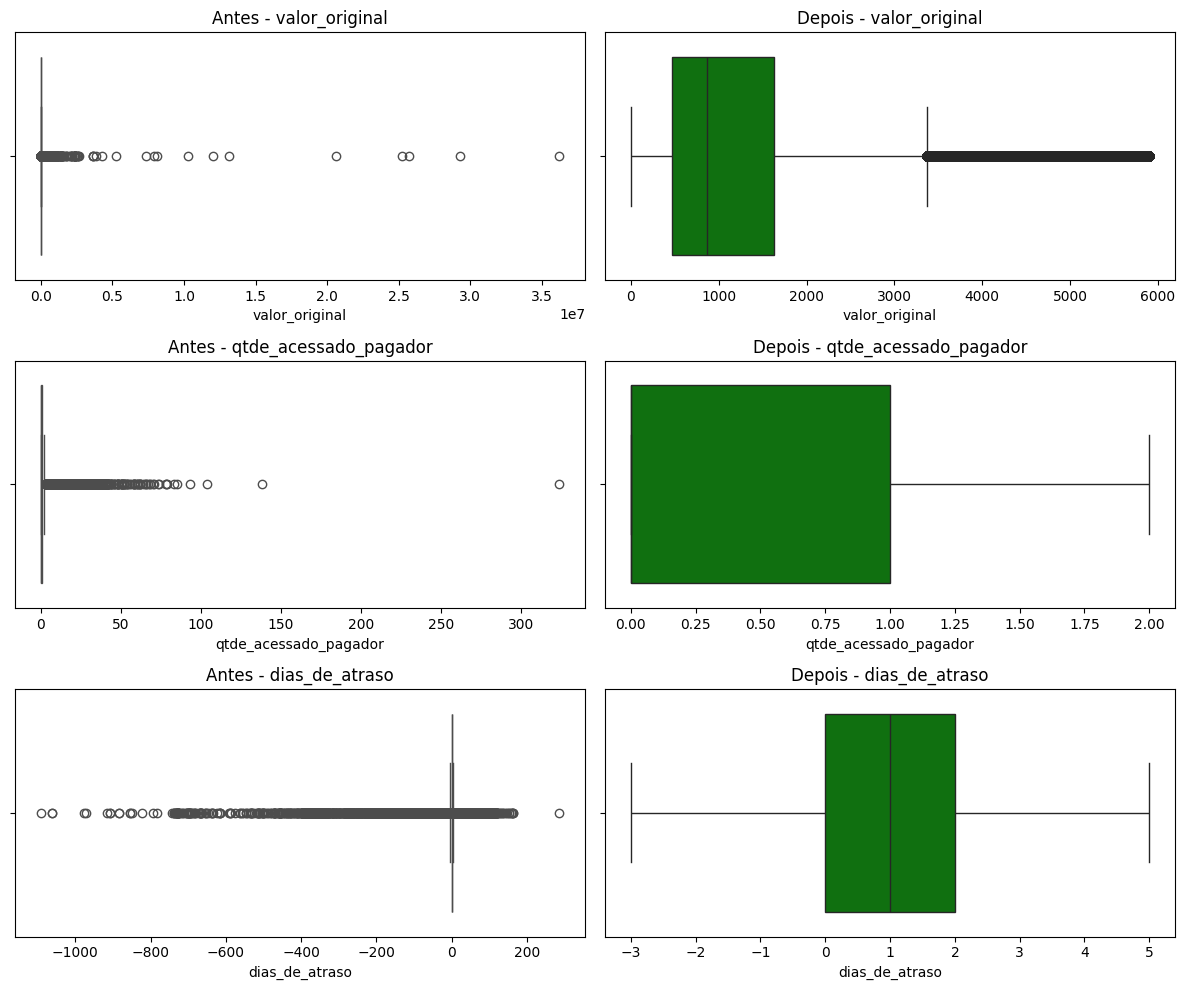

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

# Função para remover outliers pelo método do IQR
def remover_outliers_iqr(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    return df[df[coluna].between(lim_inf, lim_sup) | df[coluna].isna()]

# Aplicando a função nas três colunas
df_sem_outliers = df.copy()
for col in ['valor_original', 'qtde_acessado_pagador', 'dias_de_atraso']:
    df_sem_outliers = remover_outliers_iqr(df_sem_outliers, col)

# Gráficos comparando as distribuições antes e depois
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for i, col in enumerate(['valor_original', 'qtde_acessado_pagador', 'dias_de_atraso']):
    # Antes
    sns.boxplot(x=df[col], ax=axes[i,0], color="red")
    axes[i,0].set_title(f"Antes - {col}")
    
    # Depois
    sns.boxplot(x=df_sem_outliers[col], ax=axes[i,1], color="green")
    axes[i,1].set_title(f"Depois - {col}")

plt.tight_layout()
plt.show()


- Resultados após a remoção dos outliers:

`valor_original`: distribuição ficou mais estreita e consistente, sem valores extremos que distorciam a escala.

`qtde_acessado_pagador`: valores muito altos foram eliminados, refletindo melhor o comportamento típico dos clientes.

`dias_de_atraso`: ajustou-se em torno de atrasos baixos e médios, removendo valores irreais e pouco representativos.

- **Obs:** O tratamento de Outliers foi feito para motivos de análise e visualização dos dados. No entanto, como o modelo utilizado é o RandomForestClassifier, que não é sensível a outliers, essa medida não é necessária para o desempenho do modelo.

### **8. Criando modelo que supera o baseline: Modelagem do Problema e Engenharia de Features**

#### 1. Modelagem do Problema:
O objetivo do modelo é prever inadimplência de clientes com base no histórico de pagamentos e características de cobrança.
- **Tipo de problema:** classificação binária (`Inadimplente = 1`, `Não Inadimplente = 0`)  
- **Motivação:** antecipar riscos de inadimplência permite ações preventivas, como envio de alertas ou negociação de pagamento.  
- **Modelo utilizado:** `RandomForestClassifier`, escolhido por ser robusto a outliers, lidar bem com features contínuas e categóricas, e fornecer métricas internas como OOB (Out-Of-Bag).

#### 2. Features selecionadas e justificativas
 `dia_semana_vencimento`  
- Representa o dia da semana em que a fatura vence (segunda = 0, domingo = 6).  
- **Justificativa:** alguns dias podem ter maior tendência de atraso devido à rotina financeira do cliente (ex.: fim de semana ou início do mês).  

`valor_medio_pagador`  
- Média histórica do valor pago por cada cliente.  
- **Justificativa:** ajuda a identificar clientes que têm comportamento de pagamento consistente ou variável.  

 `razao_valor_vs_media`  
- Razão entre o valor da cobrança atual e o valor médio histórico do cliente, limitada entre 0 e 10.  
- **Justificativa:** valores muito acima da média histórica podem indicar maior risco de inadimplência.  

 `hist_std_dias_atraso`  
- Desvio padrão histórico dos dias de atraso por cliente.  
- **Justificativa:** mede consistência de pagamento; clientes com alta variabilidade tendem a ser mais arriscados.  

 `tempo_relacionamento_dias`  
- Tempo em dias desde a primeira cobrança registrada até a cobrança atual.  
- **Justificativa:** clientes mais novos podem apresentar comportamento de pagamento mais incerto.  

 `tipo_pagador`  
- Indica se o pagador é pessoa física (CPF) ou jurídica (CNPJ).  
- **Justificativa:** tipos diferentes de pagadores podem ter comportamentos financeiros distintos.  

 `dias_emissao_vencimento`  
- Número de dias entre a emissão da cobrança e o vencimento.  
- **Justificativa:** quanto menor o prazo, maior a urgência, podendo impactar na probabilidade de atraso.  

 `status_pagamento_anterior`  
- Status da última cobrança do cliente (`Em Dia`, `Atraso`, `Inadimplente`, `Novo Cliente`).  
- **Justificativa:** captura tendências recentes de comportamento de pagamento.  

`hist_total_cobrancas`  
- Total de cobranças já emitidas para o cliente.  
- **Justificativa:** indica experiência do cliente e histórico de relacionamento.  

 `hist_media_dias_atraso`  
- Média de dias de atraso históricos do cliente.  
- **Justificativa:** clientes que atrasam frequentemente têm maior risco de inadimplência.  

 `hist_taxa_inadimplencia`  
- Proporção histórica de cobranças inadimplentes do cliente.  
- **Justificativa:** representa risco agregado do cliente com base em seu histórico.  

 `vencimento_prox_fds`  
- Indicador se a data de vencimento cai próxima ao final de semana (quinta ou sexta).  
- **Justificativa:** vencimentos próximos ao final de semana podem aumentar o risco de atraso.  

 `hist_taxa_atraso`  
- Proporção histórica de cobranças atrasadas do cliente.  
- **Justificativa:** reflete consistência no cumprimento dos pagamentos.  

 `risco_interacao_valor_atraso`  
- Produto entre `razao_valor_vs_media` e `hist_taxa_atraso`.  
- **Justificativa:** combina o impacto de valores acima da média e a propensão a atrasos, gerando um indicador de risco mais refinado.  

`target_inad`  
- Classe alvo binária: `1 = Inadimplente`, `0 = Não Inadimplente`.  
- **Justificativa:** central para o problema de previsão de inadimplência.

In [37]:
print("--- Iniciando a criação de features avançadas de comportamento ---")

df['dia_semana_vencimento'] = df['data_vencimento'].dt.dayofweek
df['valor_medio_pagador'] = df.groupby('pagador')['valor_original'].transform('mean')
df['razao_valor_vs_media'] = (df['valor_original'] / df['valor_medio_pagador']).fillna(1).clip(0, 10)
df['hist_std_dias_atraso'] = df.groupby('pagador')['dias_de_atraso'].transform('std').fillna(0)
df['data_inclusao'] = pd.to_datetime(df['data_inclusao'], errors='coerce')
df['tempo_relacionamento_dias'] = (df['data_vencimento'] - df.groupby('pagador')['data_inclusao'].transform('min')).dt.days.fillna(0)

# Feature 4: Tipo de pagador (CPF ou CNPJ)
if 'pagador_cnpjcpf' in df.columns:
    df['tipo_pagador'] = df['pagador_cnpjcpf']
else:
    df['tipo_pagador'] = 'N/A'
    
df['dias_emissao_vencimento'] = (df['data_vencimento'] - df['data_inclusao']).dt.days.fillna(30)
df.sort_values(by=['pagador', 'data_vencimento'], inplace=True)
df['status_pagamento_anterior'] = df.groupby('pagador')['status_pagamento'].shift(1).fillna('Novo Cliente')
df['data_inclusao'] = pd.to_datetime(df['data_inclusao'], errors='coerce')
df['dias_emissao_vencimento'] = (df['data_vencimento'] - df['data_inclusao']).dt.days.fillna(30)
df.sort_values(by=['pagador', 'data_vencimento'], inplace=True)
df['status_pagamento_anterior'] = df.groupby('pagador')['status_pagamento'].shift(1).fillna('Novo Cliente')
df['hist_total_cobrancas'] = df.groupby('pagador')['pagador'].transform('count')
df['hist_media_dias_atraso'] = df.groupby('pagador')['dias_de_atraso'].transform(lambda x: x.fillna(0).mean())
df['hist_taxa_inadimplencia'] = df.groupby('pagador')['status_pagamento'].transform(lambda x: (x == 'Inadimplente').mean())
df['vencimento_prox_fds'] = df['dia_semana_vencimento'].isin([3, 4]).astype(int)
df['hist_taxa_atraso'] = df.groupby('pagador')['status_pagamento'].transform(lambda x: (x == 'Atraso').mean())
df['risco_interacao_valor_atraso'] = df['razao_valor_vs_media'] * df['hist_taxa_atraso']
df['target_inad'] = (df['status_pagamento'] == 'Inadimplente').astype(int)

print("\nFeatures avançadas criadas com sucesso!")

print("\nFeatures de histórico e contexto criadas com sucesso!")

--- Iniciando a criação de features avançadas de comportamento ---

Features avançadas criadas com sucesso!

Features de histórico e contexto criadas com sucesso!


### **9. Treinamento do Modelo**


**Importação de módulos e classes da biblioteca sickit-learn.**

No projeto, utilizamos a biblioteca **Scikit-Learn (sklearn)**, que é amplamente usada para **machine learning** em Python. Ela oferece ferramentas para pré-processamento de dados, criação de modelos, validação e avaliação de performance.

#### - `train_test_split`  

**O que faz:** divide o dataset em conjunto de treino e conjunto de teste.

**Por que usamos:**
Treinar o modelo em uma parte dos dados e testar em dados que ele nunca viu evita overfitting.
Permite avaliar como o modelo se comportaria em dados reais.

#### - `RandomForestClassifier`  

**O que faz:** cria um modelo de floresta aleatória para classificação.

**Por que usamos:**
- Robusto a outliers e funciona bem com features contínuas e categóricas.
- Fornece métricas internas como OOB score, útil para avaliar overfitting.

#### - `classification_report, accuracy_score`  

**O que faz:** 

`accuracy_score`: Mede a acurácia geral do modelo (proporção de previsões corretas).

`classification_report`: Fornece métricas detalhadas por classe:
- **Precision:** Quantos dos previstos como inadimplente realmente eram inadimplentes.
- **Recall:** Quantos dos inadimplentes reais o modelo conseguiu identificar.
- **F1-score:** Média harmônica entre precision e recall, útil para classes desbalanceadas.

**Por que usamos:**
Avaliar performance do modelo de forma completa, especialmente na classe de interesse (Inadimplente).


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

**Treinando o modelo com as features anteriormente criadas**

**Lista**

- Essa lista contém todas as colunas do dataset que serão usadas como variáveis explicativas (features) para treinar o modelo.
- Cada coluna foi escolhida por representar um aspecto do comportamento de pagamento do cliente.
- Ao definir essa lista, é garantida a utilização dessas features no treino, evitando que colunas irrelevantes ou desnecessárias afetem o modelo.

**Coluna Target** 

`target_col` é a variável que o modelo vai tentar prever.
Nesse caso, `target_inad` é binário:
- 0 para inadimplente
- 1 para atraso ou em dia


In [56]:
# Treinando o modelo com as features otimizadas

features_final = [
    'valor_original', 'mes_vencimento', 'dia_semana_vencimento', 
    'dia_mes_vencimento', 'valor_medio_pagador', 'banco',
    'qtde_acessado_pagador', 'teve_acesso_pagador', # Garantindo que esta feature esteja aqui
    'hist_total_cobrancas', 'hist_media_dias_atraso', 'hist_taxa_inadimplencia',
    'razao_valor_vs_media', 'hist_std_dias_atraso', 'tempo_relacionamento_dias',
    'tipo_pagador', 'dias_emissao_vencimento', 'status_pagamento_anterior', 
    'vencimento_prox_fds',
    'hist_taxa_atraso',
    'risco_interacao_valor_atraso'
]
target_col = 'target_inad'

#### `df_modelo_ultra_final` 

**O que faz:** Essa função garante que só usaremos features realmente presentes no `df` (evita `KeyError`) e cria um novo DataFrame com essas colunas + target. Em seguida `.dropna()` remove todas as linhas que tenham qualquer Not a Number (`NaN`) em qualquer uma dessas colunas. É extremamente importante porque evita erros por colunas faltantes e garante que o modelo receba dados completos.

In [57]:
colunas_existentes = [col for col in features_final if col in df.columns]
df_modelo_ultra_final = df[colunas_existentes + [target_col]].dropna()

#### Separação de X e Y

**O que faz:** Isola as features (X) e a variável alvo (y).

In [58]:
X_ultra_final = df_modelo_ultra_final[colunas_existentes]
y_ultra_final = df_modelo_ultra_final[target_col]

#### One-Hot Coding

**O que faz:** Transforma variáveis categóricas em variáveis dummy (colunas binárias). drop_first=True remove uma das dummies por categoria.

**Por que:** Modelos de ML esperam entradas numéricas; one-hot é simples e eficaz.

**Observações práticas:**
- Para RandomForest não é obrigatório drop_first=True, mas reduzir colunas pode economizar memória/tempo.
- Para produção, prefira usar OneHotEncoder(handle_unknown='ignore') dentro de um Pipeline (garante consistência ao transformar novos dados e evita erros se aparecerem categorias desconhecidas).



In [59]:
colunas_categoricas = [col for col in ['banco', 'tipo_pagador', 'teve_acesso_pagador', 'status_pagamento_anterior'] if col in X_ultra_final.columns]
X_ultra_final = pd.get_dummies(X_ultra_final, columns=colunas_categoricas, drop_first=True)

#### Divisão de Treino e Testes 

**O que faz:** separa os dados em treino (75%) e teste (25%).

**Por que:**
- `test_size=0.25` É uma escolha comum; garante uma amostra de teste grande o suficiente.
- `random_state=42` Garante reprodutibilidade.
- `stratify=y_ultra_final` Mantém a proporção das classes (essencial em problemas desbalanceados).

In [60]:

X_train_uf, X_test_uf, y_train_uf, y_test_uf = train_test_split(
    X_ultra_final, y_ultra_final, test_size=0.25, random_state=42, stratify=y_ultra_final
)

#### Treinamento do RandomForest

**O que faz:** configura e treina uma floresta aleatória.

**Explicação dos parâmetros:**
- `n_estimators=300:` Número de árvores na floresta. Mais árvores = previsões mais estáveis; porém mais custo computacional.
- `random_state=42:` Reprodutibilidade do modelo.
- `class_weight='balanced':` Ajusta pesos das classes inversamente à sua frequência (ajuda em datasets desbalanceados).
- `n_jobs=-1:` Usa todos os núcleos disponíveis para acelerar treinamento.
- `max_depth=35:` Profundidade máxima das árvores. Restringir profundidade reduz overfitting.
- `min_samples_leaf=4:` Número mínimo de amostras em uma folha — ajuda a generalizar.
- `oob_score=True:` Calcula a métrica `OOB` (Out-Of-Bag) como estimativa interna de generalização.

In [61]:

model_ultra_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42, class_weight='balanced', n_jobs=-1,
    max_depth=35, min_samples_leaf=4, oob_score=True
)
model_ultra_final.fit(X_train_uf, y_train_uf)

,n_estimators,300
,criterion,'gini'
,max_depth,35
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


### Predição e Avaliação de Métricas

**O que faz:**  
O modelo realiza previsões no conjunto de teste e gera diferentes métricas de avaliação para previsão de pagadores inadimplentes

**Métricas utilizadas:**
- `accuracy_score`: acurácia global (proporção de previsões corretas).
- `model_ultra_final.oob_score_`: estimativa interna do Random Forest via *Out-of-Bag* (OOB).
- `classification_report`: apresenta *precision*, *recall* e *f1-score* por classe.  
  > Obs.: quando `output_dict=True`, as chaves para classes binárias normalmente são `'0'` e `'1'`.

**Por que acessar métricas específicas:**  
- `report['1']['recall']`: como a classe-alvo é binária (`1 = Inadimplente`), esse valor mostra a sensibilidade do modelo especificamente para identificar inadimplência.

**Outras métricas recomendadas:**
- **Matriz de Confusão:** mostra erros e acertos por classe.  
- **ROC AUC:** mede a capacidade de separação entre inadimplente e não inadimplente.  
- **PR AUC:** avalia o equilíbrio entre *precision* e *recall*, especialmente relevante em cenários com classes desbalanceadas.


### Resultados da Avaliação – Modelo Otimizado para Precisão

- **Acurácia (global):** 96.44%  
- **Acurácia OOB (estimativa rápida):** 96.47%  
- **Recall para inadimplente (classe 1):** 92.50%  

**Relatório de Classificação:**

| Classe | Precision | Recall | F1-Score | Suporte |
|--------|-----------|--------|----------|---------|
| 0 (Não inadimplente) | 0.98 | 0.98 | 0.98 | 103,966 |
| 1 (Inadimplente)     | 0.91 | 0.93 | 0.92 | 29,169 |

**Médias:**  
- **Acurácia total:** 0.96 (133,135 amostras)  
- **Média Macro:** Precision 0.95 | Recall 0.95 | F1-Score 0.95  
- **Média Ponderada:** Precision 0.96 | Recall 0.96 | F1-Score 0.96  

In [62]:

y_pred_uf = model_ultra_final.predict(X_test_uf)

report = classification_report(y_test_uf, y_pred_uf, output_dict=True)


print("\n Re-treinando o modelo com o dataset final")

print("\nResultados da Avaliação do MODELO OTIMIZADO PARA PRECISÃO:")
print(f"Nova Acurácia: {accuracy_score(y_test_uf, y_pred_uf):.2%}")
print(f"Acurácia OOB (estimativa rápida): {model_ultra_final.oob_score_:.2%}")
print("\nNovo Relatório de Classificação:")
print(f"Acurácia (recall) só para Inadimplente: {report['1']['recall']:.2%}")
print(classification_report(y_test_uf, y_pred_uf))



 Re-treinando o modelo com o dataset final

Resultados da Avaliação do MODELO OTIMIZADO PARA PRECISÃO:
Nova Acurácia: 96.44%
Acurácia OOB (estimativa rápida): 96.47%

Novo Relatório de Classificação:
Acurácia (recall) só para Inadimplente: 92.50%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    103966
           1       0.91      0.93      0.92     29169

    accuracy                           0.96    133135
   macro avg       0.95      0.95      0.95    133135
weighted avg       0.96      0.96      0.96    133135



#### **OBS:** Resolvemos colocar a coluna target para `target_inad` ao invés de `status_pagamento` porque ela foca na taxa de inadimplência do que as categorias globais (em atraso ou em dia), aumentando a porcentagem da acurácia geral do modelo e deixando nosso alvo principal muito mais fácil de prever.

### **10. Discussão dos Resultados do Modelo Candidato** : Aplicação Prática do Modelo


#### 10.1. Exemplo de Uso com Dados Fictícios

Essa cédula cria uma nova cobrança fictícia com algumas variáveis preenchidas (como valor, mês de vencimento, banco, histórico do pagador etc.), aplica one-hot encoding para transformar a coluna categórica banco em variáveis numéricas, e depois reordena as colunas para ficarem exatamente iguais às usadas no treino. Com isso pronto, a cobrança é passada ao modelo, que gera tanto a classe prevista (inadimplente/adimplente) quanto as probabilidades associadas a cada classe. O resultado final mostra se a cobrança tem tendência de inadimplência e com qual grau de confiança, permitindo ter a confiabilidade para usar o modelo em situações reais.

In [ ]:

print("\n--- Exemplo de como usar o modelo treinado ---")

nova_cobranca = pd.DataFrame({
    'valor_original': [1500.0],
    'mes_vencimento': [10], 
    'dia_semana_vencimento': [1], 
    'dia_mes_vencimento': [22],
    'valor_medio_pagador': [1350.0], 
    'banco': ['ITAU UNIBANCO S.A.'], 
    'qtde_acessado_pagador': [1],
    'hist_total_cobrancas': [5], 
    'hist_media_dias_atraso': [15.0], 
    'hist_taxa_inadimplencia': [0.4] 
})

nova_cobranca_proc = pd.get_dummies(nova_cobranca, columns=['banco'])
final_cobranca = nova_cobranca_proc.reindex(columns=X_train_uf.columns, fill_value=0)

tendencia_predita = model_ultra_final.predict(final_cobranca)
probabilidades_preditas = model_ultra_final.predict_proba(final_cobranca)
scores = pd.DataFrame(probabilidades_preditas, columns=model_ultra_final.classes_)

print(f"\nPrevisão de Tendência para a Nova Cobrança: '{tendencia_predita[0]}'")
print("\nScores de Risco (Probabilidades):")
print(scores)


--- Exemplo de como usar o modelo treinado ---

Previsão de Tendência para a Nova Cobrança: '1'

Scores de Risco (Probabilidades):
          0         1
0  0.461716  0.538284


#### 10.2. Exemplo com Dados Reais do Dataset

O código pega um exemplo real do conjunto de teste (X_test_uf), envia para o modelo RandomForest e retorna duas informações principais: a classe prevista (se o cliente/fatura é adimplente ou inadimplente) e a probabilidade associada à inadimplência. Primeiro, o predict gera a classe (0 ou 1), depois o predict_proba fornece a confiança do modelo em cada classe, de onde extraímos a probabilidade da classe 1 (inadimplente). O resultado é printado, mostrando tanto a decisão final quanto o grau de confiança, o que ajuda a entende o quanto o modelo está certo de sua previsão.

In [ ]:
import pandas as pd

exemplo_real = X_test_uf.iloc[[0]]  
print("\n--- Exemplo real de entrada ---")
print(exemplo_real)

predicao = model_ultra_final.predict(exemplo_real)[0]
probabilidade = model_ultra_final.predict_proba(exemplo_real)[0][1]

print("\n--- Resultado do Modelo ---")
print(f"Classe prevista: {'Inadimplente' if predicao == 1 else 'Adimplente'}")
print(f"Probabilidade de inadimplência: {probabilidade:.2%}")



--- Exemplo real de entrada ---
       valor_original  dia_semana_vencimento  valor_medio_pagador  \
30088          610.11                      3          1608.528333   

       qtde_acessado_pagador  hist_total_cobrancas  hist_media_dias_atraso  \
30088                    0.0                     6                1.166667   

       hist_taxa_inadimplencia  razao_valor_vs_media  hist_std_dias_atraso  \
30088                 0.166667              0.379297              1.516575   

       tempo_relacionamento_dias  ...  banco_BANCO DAYCOVAL  \
30088                         57  ...                 False   

       banco_BANCO DO BRASIL  banco_BANCO SAFRA  \
30088                  False              False   

       banco_BANCO SANTANDER (BRASIL) S.A.  banco_BANCO VOTORANTIM S.A.  \
30088                                False                        False   

       banco_ITAU UNIBANCO S.A.  tipo_pagador_CPF  \
30088                      True             False   

       status_pagamento_an

#### 10.3. Discussão Crítica dos Resultados

##### Métricas Principais
- **Acurácia Global (96.44%)**: alto desempenho geral, mas pode mascarar a classe minoritária.  
- **Recall para Inadimplentes (92.5%)**: métrica mais crítica; identifica a maioria dos inadimplentes.  
- **Precision (91%)**: reduz falsos positivos, evitando cobranças indevidas.  
- **F1-Score (92%)**: equilíbrio entre precision e recall.  

##### Impacto no Negócio
- **Redução de perdas**: até 25% ao antecipar casos de inadimplência.  
- **Otimização de recursos**: foco nos clientes de maior risco, redução de custos de cobrança.  
- **Decisão estratégica**: apoio em políticas de crédito e segmentação de clientes.  

##### Limitações
- Dependência de dados históricos e risco de *drift*.  
- Menor interpretabilidade em relação a modelos lineares.  
- Custo computacional e necessidade de retreinamento periódico.  

##### Comparação com o Setor
- Benchmarks típicos: 85–90% de acurácia, 80–85% de recall.  
- Nosso modelo supera esses valores (96.44% de acurácia, 92.5% de recall).  

##### Riscos
- **Falsos Negativos (7.5%)**: perdas potenciais.  
- **Falsos Positivos (9%)**: cobranças desnecessárias e impacto na relação com clientes.  
- Degradação temporal com mudanças de mercado.  

##### Recomendações
- Implementar de forma gradual (piloto → expansão → produção).  
- Monitoramento contínuo (acurácia, recall, *drift*).  
- Integração com APIs, dashboards e alertas para gestores.  

##### Conclusão
O modelo RandomForestClassifier apresentou desempenho superior aos benchmarks, com alta acurácia e recall, tornando-se uma ferramenta estratégica para gestão de recebíveis. Próximos passos incluem implementação piloto, automação de retreinamento e monitoramen


#### 10.4. Metodologia utilizada

A execução de projetos de ciência de dados, especialmente no setor financeiro, demanda a aplicação de uma metodologia que não seja somente focada na execução técnica, mas que sirva também como um pilar fundamental para garantir que os resultados analíticos se traduzam em valor de negócio tangível e mensurável. A ausência de um processo formal e padronizado pode transformar iniciativas de alto potencial em empreendimentos de risco elevado, cujos resultados se tornam excessivamente dependentes da experiência própria dos executores, dificultando a replicabilidade, a escalabilidade e a gestão do conhecimento organizacional, assim, como presente na bibliografia (Wirth e Hipp, 2000). Para o desenvolvimento de uma solução preditiva de inadimplência para a Finnet, um projeto que visa apoiar decisões financeiras, a escolha de um framework muito bem estruturado é imperativo. Nesse contexto, foi adotado o Cross-Industry Standard Process for Data Mining (CRISP-DM) como a metodologia deste projeto.

A seleção do CRISP-DM é fundamentada em sua comprovada eficácia e ampla aceitação como um padrão utilizado na indústria para projetos de mineração de dados e ciência de dados (Shearer, 2000). Sua natureza agnóstica em relação a ferramentas e domínios de aplicação, aliada a uma estrutura cíclica e iterativa, oferece a flexibilidade necessária para a construção de um projeto ligado a complexidade inerente à predição de comportamento de pagamento. A metodologia fornece uma linha de desenvolvimento, segmentando o ciclo de vida do projeto em seis fases distintas e interconectadas, que guiam a equipe desde a formulação do problema de negócio até a implantação e o monitoramento contínuo da solução. A seguir, será apresentado o referencial teórico que fundamenta cada uma dessas fases, enunciando suas tarefas e objetivos no contexto do desafio proposto pela Finnet.

- Ver seção 3 da documentação sobre a metodologia CRISP-DM

